### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
# Ar=np.pi*((d0/2)**2-(dI/2)**2)
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.92664079, 0.87083673, 0.54695766, 0.17429789, 0.82815457,
       0.4870181 , 0.45664912, 0.57261425, 0.4430177 , 0.8791252 ,
       0.24609331, 0.11525164, 0.90586476, 0.1205698 , 0.64084216,
       0.54259527, 0.43483322, 0.38523934, 0.66959282, 0.14116259])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 12)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 5e2 #  to control the force from the vessel   ### !!! ### !!! ### !!! ###

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.99298566,  0.        ,  0.07100281],
        [ 0.        ,  1.        , -0.79960717],
        [-0.11823487,  0.        ,  0.59631114]],

       [[ 0.96605612,  0.        ,  0.16641426],
        [ 0.        ,  1.        , -0.76486821],
        [-0.2583323 ,  0.        ,  0.62232059]],

       [[ 0.6068737 ,  0.        ,  0.67884577],
        [ 0.        ,  1.        , -0.52009115],
        [-0.79479828,  0.        ,  0.51833736]],

       [[ 0.88682466,  0.        ,  0.4551045 ],
        [ 0.        ,  1.        , -0.17341671],
        [-0.46210608,  0.        ,  0.87338797]],

       [[ 0.98671142,  0.        ,  0.10987662],
        [ 0.        ,  1.        , -0.73668468],
        [-0.16248256,  0.        ,  0.66725019]],

       [[ 0.88659175,  0.        ,  0.40877283],
        [ 0.        ,  1.        , -0.46799277],
        [-0.46255278,  0.        ,  0.78350976]],

       [[ 0.7363523 ,  0.        ,  0.60727073],
        [ 0.        ,  1.        , -0.44094305],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.03563768,  0.        ,  0.15219867],
        [ 0.        ,  0.        , -0.17492066],
        [-0.29930012,  0.        , -0.25267739]],

       [[-0.03301659,  0.        , -0.0898727 ],
        [ 0.        ,  0.        , -0.55231143],
        [-0.12346841,  0.        , -0.6547901 ]],

       [[-0.75566942,  0.        ,  0.23091622],
        [ 0.        ,  0.        , -0.54115034],
        [-0.57699659,  0.        , -0.84540306]],

       [[-0.09082487,  0.        ,  0.14884396],
        [ 0.        ,  0.        , -0.28040523],
        [-0.17430139,  0.        , -0.13323576]],

       [[-0.10792269,  0.        ,  0.39189182],
        [ 0.        ,  0.        , -0.28983656],
        [-0.65538448,  0.        , -0.38453028]],

       [[-0.03438109,  0.        ,  0.01865573],
        [ 0.        ,  0.        , -0.16159038],
        [-0.06589949,  0.        , -0.1062515 ]],

       [[-0.50908744,  0.        ,  0.24849481],
        [ 0.        ,  0.        , -0.7484411 ],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 3.00953298e-01,  1.69471889e-01,  6.39572730e-02],
       [ 9.40417691e-01, -3.87620016e-01,  1.97878814e-01],
       [ 5.61772719e-01,  8.14956907e-01, -3.68216993e-01],
       [ 5.91735350e-01,  6.72789659e-02,  5.19461587e-01],
       [ 5.20787948e-01,  7.95238976e-03,  5.24763978e-01],
       [ 4.71960574e-01, -2.80406693e-01,  5.09317931e-01],
       [ 1.14253486e+00,  3.68673615e-01,  1.09712064e-02],
       [ 8.37827506e-01, -3.97640601e-01,  5.58844023e-01],
       [ 1.69268337e-01, -1.06523104e-02,  3.79722845e-01],
       [ 7.78693974e-01,  8.60557759e-01, -5.93633985e-02],
       [ 3.73382640e-02,  5.44906644e-01,  9.45633957e-01],
       [ 4.33051939e-01,  3.19507860e-01, -3.23066569e-01],
       [ 5.24574460e-01,  5.52410553e-01, -1.89634247e-01],
       [ 7.22195511e-01,  1.27016571e-01, -3.11903497e-01],
       [ 4.45797686e-01, -1.09125450e-01,  6.77778299e-01],
       [ 8.32067766e-01,  5.26174839e-02,  4.20454771e-01],
       [ 2.33238238e-01, -2.40628000e-01

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.26692857,  0.87780228, -0.10937712],
       [ 0.34296681,  0.1013059 , -0.24275971],
       [ 0.23766115, -0.15979893, -0.73703529],
       [ 0.49952321,  0.52595601,  0.45274981],
       [ 0.7743605 , -0.26927719, -0.41685542],
       [ 0.81826116,  0.16988841, -0.21925505],
       [ 0.52771645, -0.69747165, -1.53362564],
       [ 0.9302271 , -0.67202548, -0.14972251],
       [ 0.54380211, -0.00412043,  0.70394579],
       [ 0.01776668, -0.30599778, -0.50496042],
       [ 1.18270184,  0.52323733,  0.75865565],
       [ 0.71854496,  0.19328442,  0.14006791],
       [ 0.08147349,  0.41777294, -1.18331862],
       [ 0.59616535, -0.17459868, -0.4235476 ],
       [ 0.80695292,  0.01277058, -0.01155339],
       [ 0.80835694,  0.01945247, -0.35140341],
       [ 0.97297358, -0.14229817,  0.43680828],
       [ 0.42054361, -0.02359728, -0.03039057],
       [ 1.09828529,  0.33639045, -0.35989658],
       [ 0.47769448,  0.00775736, -0.2833287 ]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.06840943, 0.76591684, 0.03977021],
       [0.88800529, 0.04253923, 0.75138401],
       [0.8787179 , 0.82042157, 0.74075911],
       [0.28697914, 0.09091836, 0.68691752],
       [0.01639909, 0.22951838, 0.81258873],
       [0.2797636 , 0.90952081, 0.34060627],
       [0.63309618, 0.81859421, 0.38073786],
       [0.88931489, 0.13790323, 0.55337196],
       [0.86035526, 0.98630184, 0.67925985],
       [0.88301691, 0.58173639, 0.96530996],
       [0.34095138, 0.09672383, 0.62119548],
       [0.06729861, 0.24510889, 0.13031787],
       [0.25376563, 0.01037852, 0.01507128],
       [0.76919779, 0.68695286, 0.76450483],
       [0.87057782, 0.37070455, 0.93282404],
       [0.25575242, 0.08283681, 0.85788125],
       [0.18257614, 0.23348132, 0.6592831 ],
       [0.59823752, 0.95140326, 0.06527536],
       [0.91502098, 0.52534212, 0.39046865],
       [0.14781408, 0.61332172, 0.31121745]])

In [44]:
theta(φ,θ,ψ)

array([[0.92664079, 0.11851209, 0.22165785],
       [0.87083673, 0.26129551, 0.28614187],
       [0.54695766, 0.91867512, 0.06513464],
       [0.17429789, 0.48036859, 0.06389804],
       [0.82815457, 0.16320613, 0.83607049],
       [0.4870181 , 0.48087236, 0.94181644],
       [0.45664912, 0.74313314, 0.66100229],
       [0.57261425, 0.12640643, 0.73816058],
       [0.4430177 , 0.16204417, 0.91628397],
       [0.8791252 , 0.15930763, 0.56470554],
       [0.24609331, 0.01254757, 0.84436242],
       [0.11525164, 0.95859922, 0.9713008 ],
       [0.90586476, 0.9999167 , 0.90778294],
       [0.1205698 , 0.98749101, 0.83776592],
       [0.64084216, 0.12441032, 0.42319759],
       [0.54259527, 0.18196697, 0.5780649 ],
       [0.43483322, 0.16838679, 0.89056446],
       [0.38523934, 0.2174289 , 0.98492532],
       [0.66959282, 0.81273016, 0.98342389],
       [0.14116259, 0.66240943, 0.53916264]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.07681005,  0.7631983 , -0.01882407],
       [ 0.90736346, -0.54039553,  0.43590129],
       [ 0.94496284,  0.25009532, -0.32037851],
       [ 0.34561063, -0.1035179 ,  0.63004804],
       [ 0.20081507,  0.21619326,  0.78744214],
       [ 0.43016814,  0.81546973, -0.01975017],
       [ 0.65669304,  0.59333304, -0.25255444],
       [ 0.92879204, -0.29186776,  0.22303303],
       [ 0.8441761 ,  0.47137241, -0.47309566],
       [ 1.07448842, -0.16411768,  0.02680503],
       [ 0.39589525, -0.1109939 ,  0.54977446],
       [ 0.09683872,  0.2363453 ,  0.1098058 ],
       [ 0.25390337,  0.00659486,  0.01195415],
       [ 0.9430701 ,  0.15519457, -0.06312506],
       [ 1.02920247, -0.3426273 ,  0.24488032],
       [ 0.3235495 , -0.13418436,  0.80596965],
       [ 0.32762256,  0.11377958,  0.58849231],
       [ 0.39122022,  0.91464103, -0.45578973],
       [ 0.91104071,  0.21586629, -0.25290056],
       [ 0.29805289,  0.56748673,  0.16664012]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.98947626, -0.1260767 ,  0.07100281],
        [ 0.1320234 ,  0.5858312 , -0.79960717],
        [ 0.05921618,  0.80056634,  0.59631114]],

       [[ 0.98254669, -0.08311616,  0.16641426],
        [ 0.1818237 ,  0.61799414, -0.76486821],
        [-0.03927013,  0.78177679,  0.62232059]],

       [[ 0.63249233,  0.37299044,  0.67884577],
        [ 0.05559287,  0.85229961, -0.52009115],
        [-0.77256901,  0.36669265,  0.51833736]],

       [[ 0.89013195,  0.02334557,  0.4551045 ],
        [ 0.06288707,  0.98283867, -0.17341671],
        [-0.45134281,  0.18298394,  0.87338797]],

       [[ 0.75029327, -0.65191038,  0.10987662],
        [ 0.50177727,  0.4533379 , -0.73668468],
        [ 0.43044115,  0.60786315,  0.66725019]],

       [[ 0.69664463, -0.58956852,  0.40877283],
        [ 0.71461075,  0.51991753, -0.46799277],
        [ 0.06338565,  0.61813811,  0.78350976]],

       [[ 0.76441403, -0.21654895,  0.60727073],
        [ 0.55100428,  0.70849383, -0.44094305],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[-1.96574064e-02, -3.56729808e-02,  7.20823234e-01],
       [ 3.38795532e-02, -7.09543146e-01,  1.30690945e-04],
       [ 9.84378695e-01, -6.30967089e-01, -4.68886804e-01],
       [ 3.24610860e-01, -1.33252557e-01, -1.17978415e-01],
       [-4.65027305e-01, -7.31712816e-01,  2.16059559e-01],
       [-4.52605164e-01, -1.34777724e-01,  7.31652983e-01],
       [ 6.72776137e-02, -1.99889347e-01,  3.17896050e-01],
       [-2.26295369e-01,  1.25519716e-01,  3.32395349e-01],
       [-8.92026794e-01,  2.53699273e-01,  7.61469841e-01],
       [-3.91806540e-01, -7.02162469e-01,  7.81557524e-01],
       [-1.98890462e-01,  1.18895249e-01,  9.06509697e-02],
       [-2.42050951e-03, -8.05660971e-02,  1.52783058e-01],
       [ 9.07274918e-03, -1.31098841e-01, -6.24857757e-02],
       [ 4.32357669e-01, -3.06512718e-01, -1.59591896e-01],
       [-2.15271600e-01, -4.08624712e-01,  3.63294368e-01],
       [-1.32159256e-01, -4.35245263e-01,  8.14266282e-02],
       [-3.05219228e-01, -2.39791774e-01

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[-0.01569757, -0.18648828,  0.16533196],
       [ 0.02439535, -0.29518653,  0.19531064],
       [ 0.4259824 , -0.24380819, -0.13838749],
       [ 0.04186912, -0.01604649,  0.00642479],
       [-0.44758735, -0.40943587,  0.52327401],
       [-0.20874421, -0.5195821 ,  0.37323078],
       [ 0.203515  , -0.42919553,  0.34192691],
       [-0.27059873, -0.16595756,  0.23833133],
       [-0.33222613, -0.19271617,  0.19471102],
       [-0.19007938, -0.33239227,  0.38968308],
       [-0.17332736, -0.01569585,  0.0507503 ],
       [ 0.38149707, -0.77826256,  0.72281802],
       [ 0.71871168, -1.28848313,  0.70206233],
       [ 0.38989391, -0.59408271,  0.64414401],
       [-0.08641066, -0.12216833,  0.16676511],
       [-0.13808366, -0.14936927,  0.17663036],
       [-0.30595288, -0.18776458,  0.18488898],
       [-0.32609959, -0.25309685,  0.18342199],
       [ 0.16332353, -0.97398497,  0.69372597],
       [ 0.09494263, -0.18985764,  0.20839934]])

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[-1.96574064e+07, -3.56729808e+07,  7.20823234e+08],
       [ 3.38795532e+07, -7.09543146e+08,  1.30690945e+05],
       [ 9.84378695e+08, -6.30967089e+08, -4.68886804e+08],
       [ 3.24610860e+08, -1.33252557e+08, -1.17978415e+08],
       [-4.65027305e+08, -7.31712816e+08,  2.16059559e+08],
       [-4.52605164e+08, -1.34777724e+08,  7.31652983e+08],
       [ 6.72776137e+07, -1.99889347e+08,  3.17896050e+08],
       [-2.26295369e+08,  1.25519716e+08,  3.32395349e+08],
       [-8.92026794e+08,  2.53699273e+08,  7.61469841e+08],
       [-3.91806540e+08, -7.02162469e+08,  7.81557524e+08],
       [-1.98890462e+08,  1.18895249e+08,  9.06509697e+07],
       [-2.42050951e+06, -8.05660971e+07,  1.52783058e+08],
       [ 9.07274918e+06, -1.31098841e+08, -6.24857757e+07],
       [ 4.32357669e+08, -3.06512718e+08, -1.59591896e+08],
       [-2.15271600e+08, -4.08624712e+08,  3.63294368e+08],
       [-1.32159256e+08, -4.35245263e+08,  8.14266282e+07],
       [-3.05219228e+08, -2.39791774e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[-4.15250952e+07, -6.75048142e+08, -3.45400286e+07],
       [-3.32672621e+07, -1.70489405e+06, -6.32147188e+08],
       [-6.67862772e+08, -2.18323735e+08, -1.10831610e+09],
       [-5.86619877e+07,  1.36372818e+07, -1.76807944e+08],
       [ 2.11926304e+08, -3.93250753e+08, -8.75661778e+08],
       [ 9.84398293e+07, -8.29624410e+08, -9.19295294e+07],
       [ 1.69147512e+08, -2.25895713e+08, -1.77837968e+08],
       [-1.59119129e+08, -3.37754868e+08,  1.92149891e+07],
       [-3.64834385e+08, -1.09963934e+09, -6.10192861e+07],
       [-6.36298833e+07, -8.07736871e+08, -7.57580986e+08],
       [-1.14500814e+08, -1.85487339e+08, -7.93765873e+06],
       [ 1.66464976e+08, -1.31874428e+08, -6.69032155e+07],
       [-7.80881996e+07,  5.58664835e+07, -1.28549351e+08],
       [-3.19524464e+07,  2.75925585e+08, -6.16507412e+08],
       [ 5.83303628e+07, -3.01651667e+08, -3.04726593e+08],
       [ 1.59680720e+08, -1.02113741e+08, -2.86653612e+08],
       [ 1.38426550e+08, -3.16367746e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 9358793.42684291,  -587271.13668054,   226157.9351474 ],
       [ 8888952.3250843 ,   424346.91880651,  -468932.83558762],
       [ 3761505.96688429,  8847991.67500397, -4009592.93308195],
       [ 1836519.53216029,  4692875.99539619,  -247363.39704034],
       [ 9090141.70091257, -4527141.91081439,  4233075.13148188],
       [ 8167752.01463628,   401090.71865725,  5126507.95034536],
       [ 7376619.74877759,  4516687.70082561,  1278897.24465078],
       [ 6462612.73759677, -2735519.62249178,  5432750.43058898],
       [ 5707723.54694161, -2307372.59300177,  7455083.28904489],
       [ 9251307.10814217, -2756179.66983762,  2161628.10339195],
       [ 2563491.63486146, -1931533.36620883,  8157708.378589  ],
       [ 8558581.64288167,  8469028.62100931,  4601509.59990735],
       [ 9607927.80662941,  2855287.31554991, -4595518.51839869],
       [ 7605703.93392173,  8867262.91991011,  3574464.51425769],
       [ 6779842.78773334, -1286071.2780139 ,  2570882.40155668],
       [ 6

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-1.81898940e-12, -1.41574755e-10, -2.32830644e-10],
       [ 7.27595761e-12, -1.22518596e-10,  5.82076609e-11],
       [-9.31322575e-10, -4.78777230e-10, -1.86264515e-09],
       [-1.01863407e-10,  4.28129374e-11,  1.16415322e-10],
       [ 0.00000000e+00,  1.22527806e-09,  9.31322575e-10],
       [ 1.74622983e-10,  2.39354995e-10, -3.49245965e-10],
       [ 0.00000000e+00,  7.30180808e-12,  0.00000000e+00],
       [-2.32830644e-10, -1.23597606e-09, -4.65661287e-10],
       [ 0.00000000e+00,  1.07707908e-09,  4.65661287e-10],
       [ 1.16415322e-10, -8.08041469e-11, -9.31322575e-10],
       [-2.32830644e-10, -1.21116789e-10,  1.16415322e-10],
       [-4.65661287e-10, -7.05684551e-10,  2.79396772e-09],
       [ 4.65661287e-10, -1.71807666e-09,  0.00000000e+00],
       [-4.65661287e-10, -1.50415028e-10,  0.00000000e+00],
       [ 5.82076609e-11,  2.64393745e-10,  0.00000000e+00],
       [ 2.32830644e-10, -5.41333100e-10, -3.49245965e-10],
       [-4.65661287e-10, -2.60370143e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[  4.4376473 ,  45.96932914, 232.99144872],
       [  7.99668864, 304.51843612,  85.06319797],
       [176.07725324, 200.00700824, 289.60051526],
       [127.16764057,  86.98421957, 327.88675805],
       [ 65.92845463, 308.1221168 , 256.31676217],
       [150.12302117, 251.19073039, 431.36443739],
       [217.92905001,  54.68135624,  43.22468665],
       [367.7974326 , 160.66352304, 406.97355644],
       [294.96318128, 129.25050048, 208.63109944],
       [220.12309096,  27.6879844 , 329.12409197],
       [ 72.03728612, 512.66011661, 439.17422374],
       [198.12774524, 487.41438968, 523.23881479],
       [  0.54178429, 274.02653109,  15.40940799],
       [255.3892652 , 363.0617865 , 109.08988937],
       [ 67.55560549,  85.72412874, 224.39748583],
       [175.34532072,  53.10444858,  86.02362591],
       [145.82529399, 203.44316883, 207.5542339 ],
       [185.76031288, 155.98185355,  95.65363232],
       [ 49.77846596,  76.21946087,  48.85480505],
       [ 59.12348899, 352.63936

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569,  6808.77525521],
       [ 5845.36330569,  5845.36330569, 24047.23857524],
       [ 5845.36330569,  5845.36330569, 23789.85605217],
       [ 5845.36330569,  5845.36330569, 22485.57237397],
       [ 5845.36330569,  5845.36330569, 25529.8902785 ],
       [ 5845.36330569,  5845.36330569, 14096.36786268],
       [ 5845.36330569,  5845.36330569, 15068.53416975],
       [ 5845.36330569,  5845.36330569, 19250.50274469],
       [ 5845.36330569,  5845.36330569, 22300.06937847],
       [ 5845.36330569,  5845.36330569, 29229.48013064],
       [ 5845.36330569,  5845.36330569, 20893.49111169],
       [ 5845.36330569,  5845.36330569,  9002.24403783],
       [ 5845.36330569,  5845.36330569,  6210.45691878],
       [ 5845.36330569,  5845.36330569, 24365.08344019],
       [ 5845.36330569,  5845.36330569, 28442.52616156],
       [ 5845.36330569,  5845.36330569, 26627.07725688],
       [ 5845.36330569,  5845.36330569, 21816.14339448],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-4.43764730e+00, -4.59693291e+01, -5.08162600e+02],
       [-7.99668864e+00, -3.04518436e+02, -3.60234350e+02],
       [-1.76077253e+02, -2.00007008e+02, -5.64771667e+02],
       [-1.27167641e+02, -8.69842196e+01, -6.03057910e+02],
       [-6.59284546e+01, -3.08122117e+02, -5.31487914e+02],
       [-1.50123021e+02, -2.51190730e+02, -7.06535589e+02],
       [-2.17929050e+02, -5.46813562e+01, -3.18395838e+02],
       [-3.67797433e+02, -1.60663523e+02, -6.82144708e+02],
       [-2.94963181e+02, -1.29250500e+02, -4.83802251e+02],
       [-2.20123091e+02, -2.76879844e+01, -6.04295244e+02],
       [-7.20372861e+01, -5.12660117e+02, -7.14345375e+02],
       [-1.98127745e+02, -4.87414390e+02, -7.98409966e+02],
       [-5.41784287e-01, -2.74026531e+02, -2.90580560e+02],
       [-2.55389265e+02, -3.63061787e+02, -3.84261041e+02],
       [-6.75556055e+01, -8.57241287e+01, -4.99568638e+02],
       [-1.75345321e+02, -5.31044486e+01, -3.61194778e+02],
       [-1.45825294e+02, -2.03443169e+02

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', RET, Jrho0, RET)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[100.50413984,  -5.67743523,   4.23397636],
        [ -5.67743523, 163.93716288, -47.68146621],
        [  4.23397636, -47.68146621, 135.55869729]],

       [[102.76937049, -12.72849752,  10.35630178],
        [-12.72849752, 158.50233831, -47.59932346],
        [ 10.35630178, -47.59932346, 138.7282912 ]],

       [[146.08315762, -35.30616739,  35.18711255],
        [-35.30616739, 127.04948012, -26.9582674 ],
        [ 35.18711255, -26.9582674 , 126.86736226]],

       [[120.71201028,  -7.89227252,  39.74827911],
        [ -7.89227252, 103.00733559, -15.14600693],
        [ 39.74827911, -15.14600693, 176.28065414]],

       [[101.20728721,  -8.09444241,   7.33151964],
        [ -8.09444241, 154.27043178, -49.15529895],
        [  7.33151964, -49.15529895, 144.52228102]],

       [[116.70952251, -19.13027297,  32.02774992],
        [-19.13027297, 121.90172361, -36.66769042],
        [ 32.02774992, -36.66769042, 161.38875388]],

       [[136.8777742 , -26.77718111,  40.13464541],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

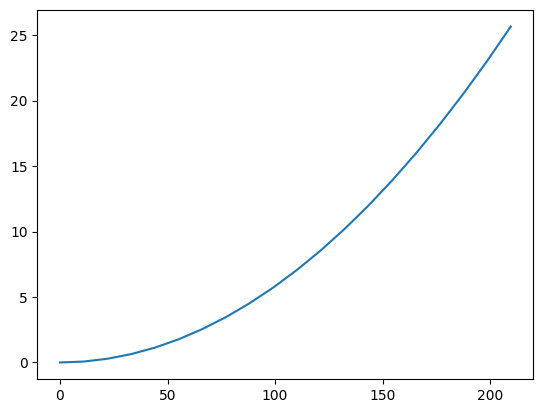

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 6.224e+01  6.224e+01 ...  0.000e+00  0.000e+00]
       x: [ 1.058e+03  1.069e+03 ...  0.000e+00  0.000e+00]
     nit: 330
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

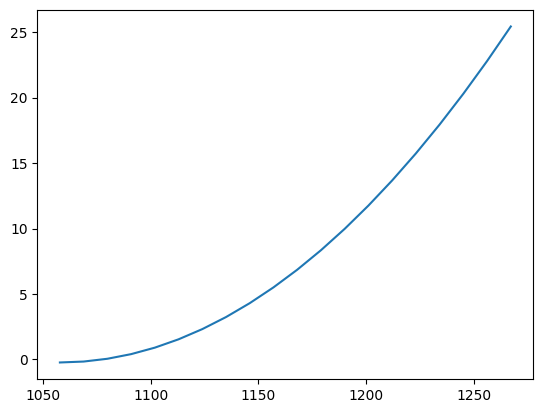

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Finite Element Model of the Space Frame Element

In [87]:
def PlaneTrussElementLength(x1,y1,z1,x2,y2,z2):
    return np.sqrt((x2-x1)*(x2-x1) + (y2-y1)*(y2-y1)+(z2-z1)*(z2-z1))

In [88]:
def SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,x1,y1,z1,x2,y2,z2):
    L = PlaneTrussElementLength(x1,y1,z1,x2,y2,z2)
    w1 = E*A/L
    w2 = 12*E*Iz/(L*L*L)
    w3 = 6*E*Iz/(L*L)
    w4 = 4*E*Iz/L
    w5 = 2*E*Iz/L
    w6 = 12*E*Iy/(L*L*L)
    w7 = 6*E*Iy/(L*L)
    w8 = 4*E*Iy/L
    w9 = 2*E*Iy/L
    w10 = G*J/L

    kprime = np.array([[w1, 0, 0, 0, 0, 0, -w1, 0, 0, 0, 0, 0],
                        [0, w2, 0, 0, 0, w3, 0, -w2, 0, 0, 0, w3],
                        [0, 0, w6, 0, -w7, 0, 0, 0, -w6, 0, -w7, 0],
                        [0, 0, 0, w10, 0, 0, 0, 0, 0, -w10, 0, 0],
                        [0, 0, -w7, 0, w8, 0, 0, 0, w7, 0, w9, 0],
                        [0, w3, 0, 0, 0, w4, 0, -w3, 0, 0, 0, w5],
                        [-w1, 0, 0, 0, 0, 0, w1, 0, 0, 0, 0, 0],
                        [0, -w2, 0, 0, 0, -w3, 0, w2, 0, 0, 0, -w3],
                        [0, 0, -w6, 0, w7, 0, 0, 0, w6, 0, w7, 0],
                        [0, 0, 0, -w10, 0, 0, 0, 0, 0, w10, 0, 0],
                        [0, 0, -w7, 0, w9, 0, 0, 0, w7, 0, w8, 0],
                        [0, w3, 0, 0, 0, w5, 0, -w3, 0, 0, 0, w4]])


    if x1 == x2 and y1 == y2:
        if z2 > z1:
            Lambda = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]])
        else:
            Lambda = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]])
    else:
        CXx = (x2-x1)/L
        CYx = (y2-y1)/L
        CZx = (z2-z1)/L
        D = np.sqrt(CXx*CXx + CYx*CYx)
        CXy = -CYx/D
        CYy = CXx/D
        CZy = 0
        CXz = -CXx*CZx/D
        CYz = -CYx*CZx/D
        CZz = D
        Lambda = np.array([[CXx, CYx, CZx], [CXy, CYy, CZy], [CXz, CYz, CZz]])


    R = np.array([np.concatenate((np.concatenate((Lambda,np.zeros((3,3)),np.zeros((3,3)),np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), Lambda, np.zeros((3,3)), np.zeros((3,3))),axis=1) ,
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), Lambda, np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3)), Lambda),axis=1)))])[0]
    return np.dot(np.dot(R.T,kprime),R)

In [89]:
def SpaceFrameAssemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]

    return K

In [90]:
def FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs,
          E=210e6, G=84e6, A=2e-2, Iy=10e-5, Iz=20e-5, J=5e-5):

    coord=np.array(coord)
    elcon=np.array(elcon)

    K=np.zeros(shape=(6*(np.max(elcon)+1),6*(np.max(elcon)+1)))

    for el in elcon:
        k=SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,
                                     coord[el[0]][0],coord[el[0]][1],coord[el[0]][2],\
                                     coord[el[1]][0],coord[el[1]][1],coord[el[1]][2])
        K=SpaceFrameAssemble(K,k,el[0],el[1])
        
        
    glob_force=np.dot(K, np.array(vessel_movement))
    
    glob_force[-6:]=np.multiply(glob_force[-6:], coefs)
    glob_force = np.zeros(len(vessel_movement))


    F=np.zeros(len(coord)*6)
    for i in range(len(vessel_movement)):
        if vessel_movement[i]:
            F[i]=glob_force[i]

    # https://github.com/CALFEM/calfem-matlab/blob/master/fem/solveq.m

    bc=np.array([bc_node,
                bc_val]).T
    nd, nd=K.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    s=scipy.linalg.lstsq(K[fdof,:][:,fdof], (F[fdof].T-np.dot(K[fdof,:][:,pdof],dp.T)).T, check_finite=True)[0]
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    

#     Q=np.dot(K,d).T-F
    return d, np.dot(K,d).T

In [91]:
# 10 The Space Frame Element - verification
d,f=FEA(np.array([0,0,0,
                  3,0,0,
                  0,0,-3,
                  0,-4,0]).reshape(4,3),
        elcon=np.array([[0, 1],
                      [0, 2],
                      [0, 3]]),
        bc_node=list(range(6)),
        bc_val=[ -0.0705e-4, -0.0007e-4, 0.1418e-4, 0.0145e-4, 0.0175e-4,0.0114e-4],
        vessel_movement=[ 0, 0, 0, 0, 0,0.0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                       ],
        coefs=[1,1,1,1,1,1])

In [92]:
d

array([-7.050e-06, -7.000e-08,  1.418e-05,  1.450e-06,  1.750e-06,
        1.140e-06, -7.050e-06,  3.350e-06,  8.930e-06,  1.450e-06,
        1.750e-06,  1.140e-06, -1.230e-05,  4.280e-06,  1.418e-05,
        1.450e-06,  1.750e-06,  1.140e-06, -2.490e-06, -7.000e-08,
        8.380e-06,  1.450e-06,  1.750e-06,  1.140e-06])

In [93]:
f

array([ 2.18575158e-15, -1.86923231e-17, -3.84067778e-15,  9.71445147e-17,
        4.94078553e-17, -1.38777878e-17, -5.59719372e-16, -2.94360890e-17,
        2.29749217e-17,  3.06625927e-19,  2.51331616e-17,  5.88721780e-17,
        1.93123512e-17,  1.42708111e-17,  1.72398987e-15, -2.85416222e-17,
        6.63802780e-17, -6.09863722e-20,  2.08166817e-17,  4.64478987e-17,
        2.42861287e-17,  1.38777878e-17,  3.17637355e-20, -1.38777878e-17])

In [94]:
def PipeForce(X,Y,Z,vessel_movement,coefs, E=E, G=G, A=Ar, Iy=Iy_, Iz=Iz_, J=J_):
    coord=np.stack((X,Y,Z)).T
    elcon=[]
    for i in range(1,len(X)):
        elcon.append([i-1,i])
    
    bc_node = list(range(3))+list(range((6*len(X)-6),6*len(X)))
    bc_val = [0]*3 + vessel_movement
    
    vessel_move=np.zeros(len(X)*6)

    d, f = FEA(coord,elcon,bc_node,bc_val,vessel_move, coefs, E,G,A,Iy,Iz,J)

    fors=[]
    for i in range(0,len(f),6):
        fors.append(f[i:i+3])

    mom =[]
    for i in range(3,len(f),6):
        mom.append(f[i:i+3])

    angle=[]
    for i in range(3,len(d),6):
        angle.append(d[i:i+3])
    fors[0][0]=0
    fors[0][1]=0
    fors[0][2]=0
    return np.array(fors), np.array(mom), np.array(angle)

In [95]:
fors, mom, angle = PipeForce(x0_,list([0 for i in range(len(z0))]),z0_,
[0.01,
 0.02,
 0.03,
 0.01,
 -0.05,
 0.03],
 [1,1,1,1,1,1]
)

In [96]:
fors

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 8.68445262e-04,  2.36511230e-04,  1.01947784e-03],
       [ 8.10623169e-05,  9.15527344e-05,  1.26266479e-03],
       [ 3.67760658e-04,  9.31739807e-04, -2.23922729e-03],
       [-7.35759735e-04,  3.96728516e-04,  2.52056122e-03],
       [ 2.20775604e-04, -1.52587891e-04, -2.39181519e-03],
       [ 2.51770020e-04, -5.87463379e-04,  2.62451172e-03],
       [ 5.81264496e-04, -5.96046448e-04, -2.12478638e-03],
       [ 1.38878822e-04, -1.11389160e-03,  1.06978416e-03],
       [ 2.15768814e-04, -7.62939453e-04, -1.52587891e-04],
       [ 7.34329224e-05, -1.52587891e-05, -9.07897949e-04],
       [-5.61714172e-04,  1.83105469e-04,  1.94549561e-03],
       [ 2.85625458e-04,  5.79833984e-04, -3.08918953e-03],
       [-6.51359558e-04,  1.35803223e-03,  3.93295288e-03],
       [ 1.02615356e-03,  4.73022461e-04, -4.44030762e-03],
       [-7.08239670e-04, -6.31462020e-04,  4.73650431e-03],
       [ 9.13667675e-04, -1.04998236e-03

In [97]:
mom

array([[ 3.57627869e-04,  1.85958482e-03, -3.05175781e-05],
       [-1.12295151e-04,  1.75476074e-04,  6.39915466e-04],
       [-3.50713730e-04, -2.67028809e-04,  2.44140625e-04],
       [-4.38690186e-04, -1.06811523e-04,  5.64575195e-04],
       [-7.01904297e-04,  2.17437744e-04,  2.44140625e-04],
       [-7.86781311e-05, -2.31933594e-03, -2.17437744e-04],
       [ 2.55584717e-04, -6.13212585e-04,  6.10351562e-05],
       [ 4.63485718e-04, -1.70898438e-03, -4.73022461e-04],
       [ 1.67846680e-04,  1.89304352e-04,  7.93457031e-04],
       [ 2.96592712e-04, -7.32421875e-04,  6.29425049e-04],
       [ 0.00000000e+00,  6.00814819e-05,  1.22070312e-04],
       [-2.76565552e-04,  1.58691406e-03,  4.57763672e-04],
       [-1.67846680e-04, -1.20162964e-04, -1.09863281e-03],
       [-6.77108765e-05, -1.83105469e-04, -1.21307373e-03],
       [-1.06811523e-04, -3.41892242e-04, -4.88281250e-04],
       [ 2.04202501e-04,  8.63075520e-04,  1.22712364e-04],
       [-1.28896868e-04, -5.14287287e-04

In [98]:
angle

array([[-0.37716846,  0.01905929, -0.04143285],
       [-0.37716847,  0.01898777, -0.0414322 ],
       [-0.37682588,  0.01875328, -0.04142365],
       [-0.37579827,  0.01831588, -0.04138742],
       [-0.37374356,  0.01763548, -0.04129054],
       [-0.37032016,  0.01667179, -0.04108688],
       [-0.36518718,  0.01538427, -0.04071713],
       [-0.35800453,  0.01373209, -0.04010885],
       [-0.34843317,  0.0116741 , -0.03917646],
       [-0.33613518,  0.00916875, -0.0378213 ],
       [-0.32077401,  0.00617405, -0.03593161],
       [-0.30201456,  0.00264755, -0.03338259],
       [-0.27952338, -0.00145373, -0.03003643],
       [-0.25296882, -0.00617336, -0.02574232],
       [-0.22202116, -0.0115555 , -0.02033652],
       [-0.18635277, -0.01764501, -0.01364238],
       [-0.14563825, -0.02448746, -0.00547038],
       [-0.09955454, -0.0321292 ,  0.00438182],
       [-0.0477811 , -0.04061736,  0.01612933],
       [ 0.01      , -0.05      ,  0.03      ]])

### Vessle Simulation

In [99]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [100]:
Number*sampleTime

600.0

In [101]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [102]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [103]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

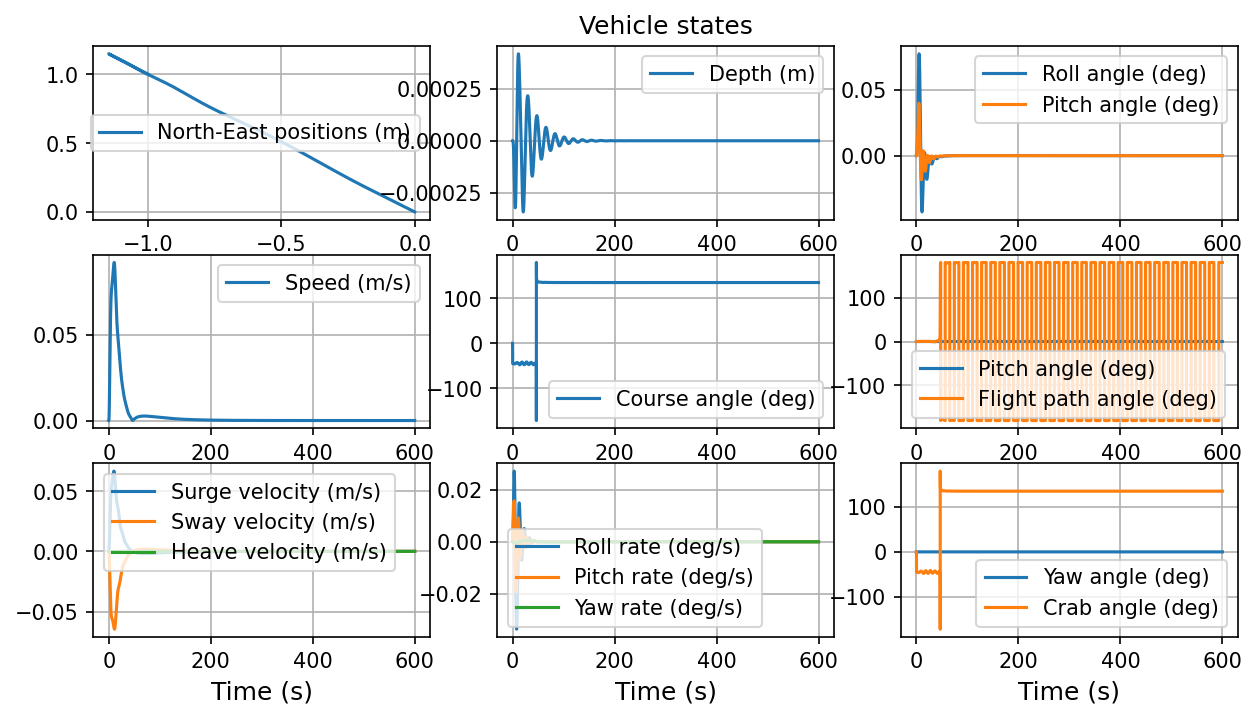

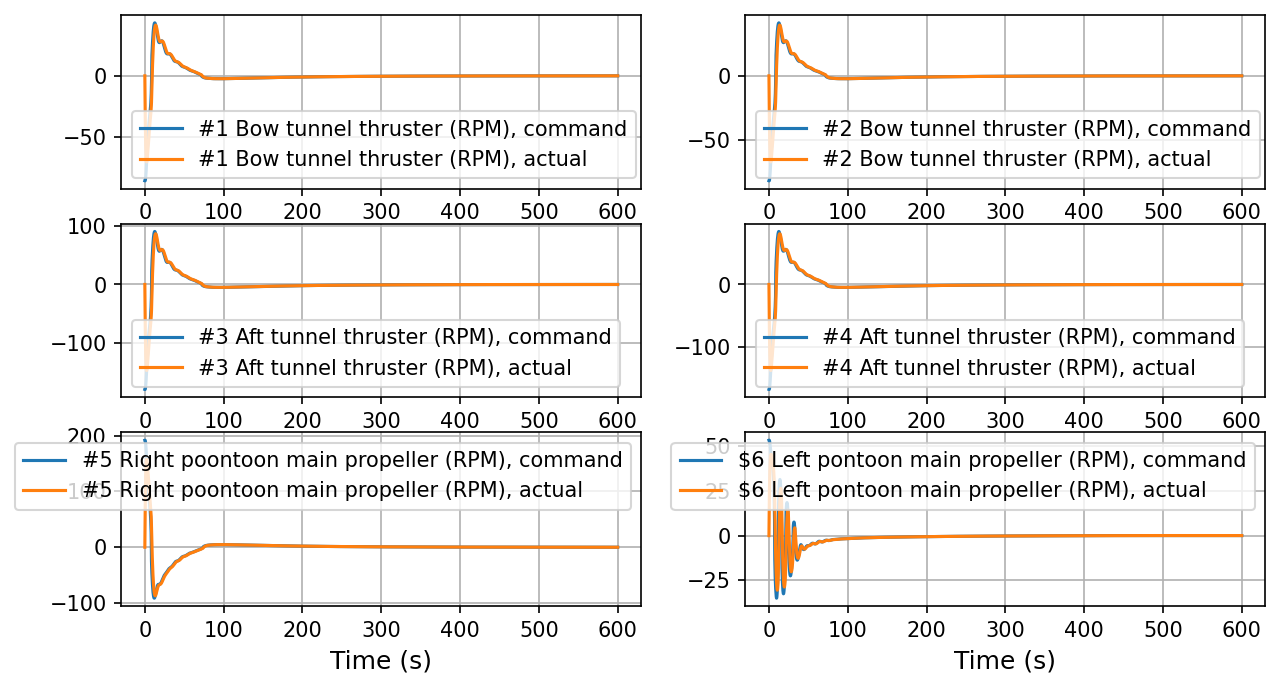

In [104]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [105]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

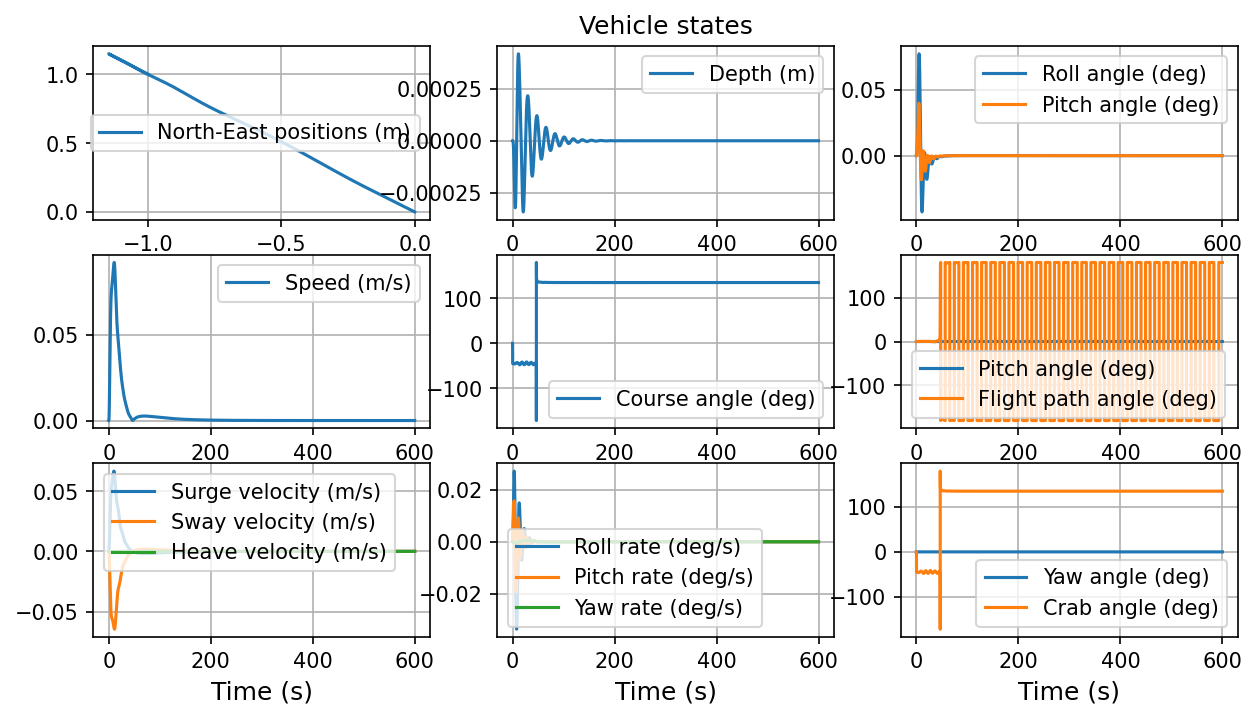

In [106]:
plotVehicleStates(simTime, simData, 3)

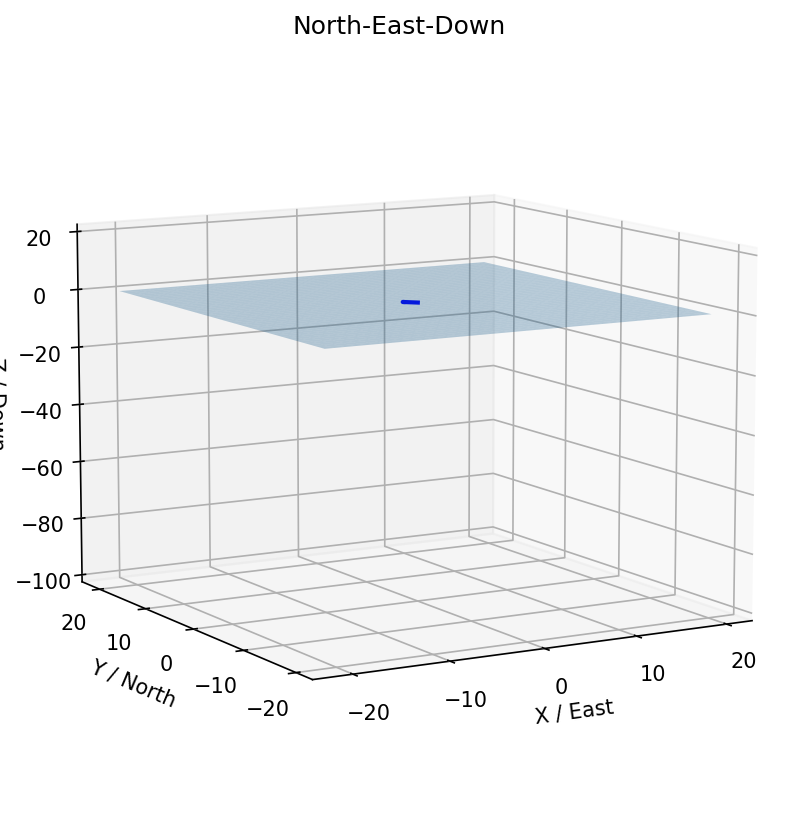

In [107]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [108]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [109]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [110]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    del_t = idx-T.my_t
    if del_t<0:
        idx=T.my_t
        
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    
    RET = Ret(φ,θ,ψ)

    vessel_movement = np.zeros(6)
    
    
    vessel_movement[0] = (x_ve - T.x_ve)
    vessel_movement[1] = (y_ve - T.y_ve)
    vessel_movement[2] = (z_ve - T.z_ve)
    vessel_movement[3] = (phi_ve - T.phi_ve)
    vessel_movement[4] = (theta_ve - T.theta_ve)
    vessel_movement[5] = (psi_ve - T.psi_ve)

    vessel_movement/=calibr
    

    fors, mom, angle = PipeForce(x, y, z, list(vessel_movement), coefs)
    
    Z0 = fors.squeeze()
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T

    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,ik->ij', Π(φ,θ,ψ), angle).squeeze()    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T - C0)

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################

    T.my_t=idx
    T.x_ve=x_ve
    T.y_ve=y_ve
    T.z_ve=z_ve
    T.phi_ve = phi_ve
    T.theta_ve = theta_ve
    T.psi_ve = psi_ve

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [111]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.000001 for i in range(N)]),
                                          np.array([0.001257*i/N for i in range(N)]))

In [112]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  9.84646067382047e-08  Iteration wall-clock time:  0:00:00.351494
Physical time:  1.0098872434211323  Iteration wall-clock time:  0:00:55.046780
Physical time:  2.011916967249009  Iteration wall-clock time:  0:01:12.732115
Physical time:  3.002827916583998  Iteration wall-clock time:  0:00:56.408828
Physical time:  4.0021163588235975  Iteration wall-clock time:  0:00:52.406426
Physical time:  5.000111181341153  Iteration wall-clock time:  0:00:47.267910
Physical time:  6.008956812471384  Iteration wall-clock time:  0:00:49.728244
Physical time:  7.002101504203965  Iteration wall-clock time:  0:01:06.362001
Physical time:  8.001642162705718  Iteration wall-clock time:  0:00:48.382445
Physical time:  9.009060405803572  Iteration wall-clock time:  0:00:56.833564
Physical time:  10.001355669885132  Iteration wall-clock time:  0:00:52.207056
Physical time:  11.005876931338975  Iteration wall-clock time:  0:00:59.796357
0:11:14.486348


In [113]:
# max axial tension
T_.top_tension

381614.85456127016

In [114]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.00012437758151377513

### Results

In [115]:
fin=us_

In [116]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.846e-06 ...  1.199e+01  1.200e+01]
        y: [[ 0.000e+00  3.337e-25 ...  1.006e-04  1.007e-04]
            [ 1.103e+01  1.103e+01 ...  1.053e+01  1.053e+01]
            ...
            [ 0.000e+00 -4.271e-20 ...  3.260e-11  3.265e-11]
            [ 0.000e+00 -3.577e-20 ... -1.972e-11 -1.969e-11]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1874
     njev: 0
      nlu: 0

In [117]:
t=fin.t

In [118]:
fin=fin.y.T

In [119]:
t.shape, fin.shape

((272,), (272, 240))

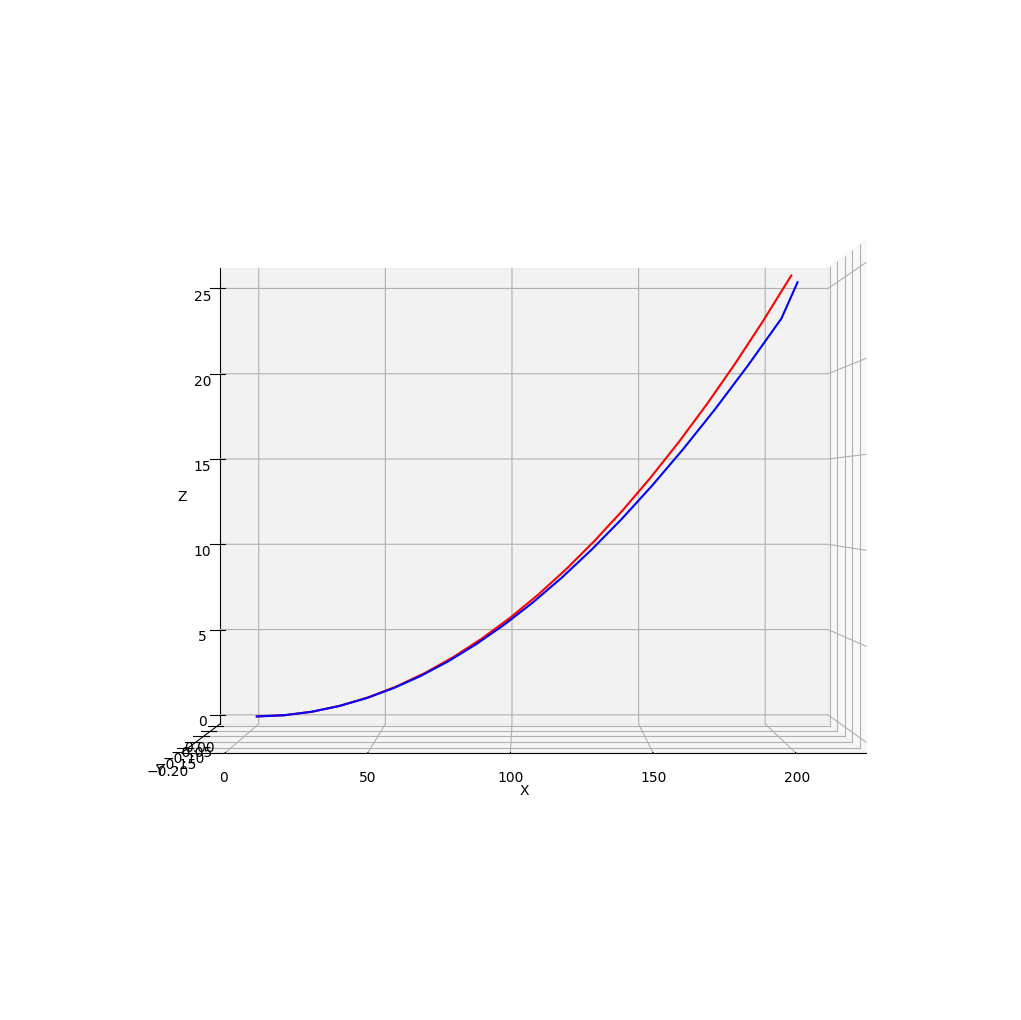

In [120]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [121]:
X,Y,Z

(array([1.00728529e-04, 1.05335711e+01, 2.12410089e+01, 3.20178264e+01,
        4.28346165e+01, 5.36793557e+01, 6.45464849e+01, 7.54336451e+01,
        8.63403147e+01, 9.72672436e+01, 1.08216021e+02, 1.19188497e+02,
        1.30186280e+02, 1.41209362e+02, 1.52255086e+02, 1.63315121e+02,
        1.74380338e+02, 1.85444718e+02, 1.96505316e+02, 2.01407894e+02]),
 array([ 1.01786837e-08,  2.29527104e-04, -3.55526513e-04, -2.30928710e-03,
        -5.73762367e-03, -1.06124735e-02, -1.69290933e-02, -2.46995902e-02,
        -3.38627204e-02, -4.44256507e-02, -5.64395037e-02, -6.98293690e-02,
        -8.45477121e-02, -1.00866492e-01, -1.18473555e-01, -1.37518232e-01,
        -1.57962495e-01, -1.79780005e-01, -2.02942657e-01, -2.20794765e-01]),
 array([-1.31195978e-03,  6.52360785e-02,  2.66557422e-01,  6.03528627e-01,
         1.07681029e+00,  1.68676182e+00,  2.43382135e+00,  3.31834704e+00,
         4.34061604e+00,  5.50111507e+00,  6.80026741e+00,  8.23860462e+00,
         9.81682477e+00,  1.

In [122]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [123]:
us=fin.T

In [124]:
us.shape

(240, 272)

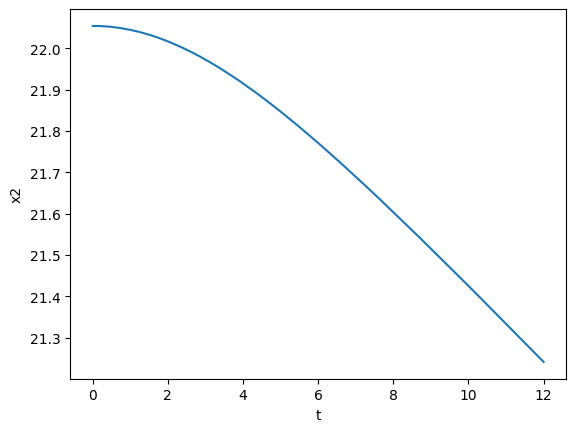

In [125]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

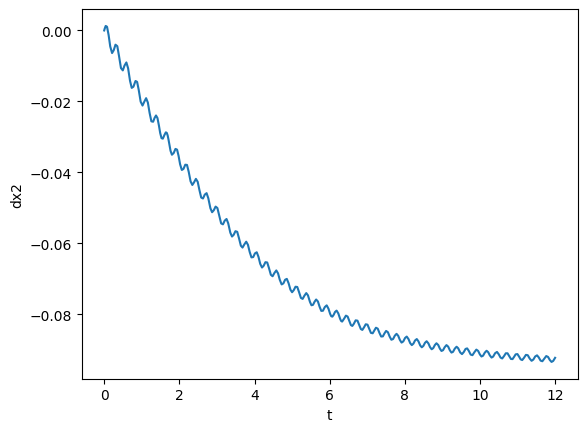

In [126]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

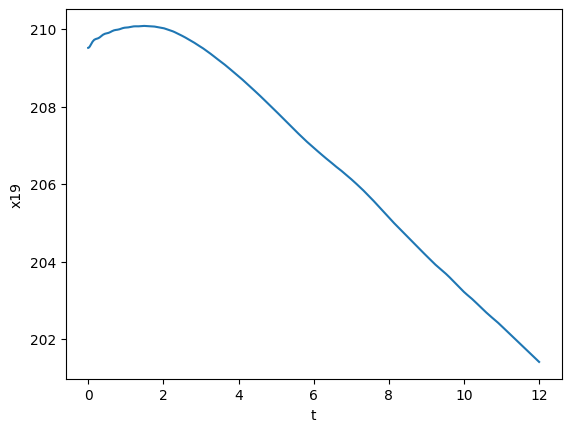

In [127]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

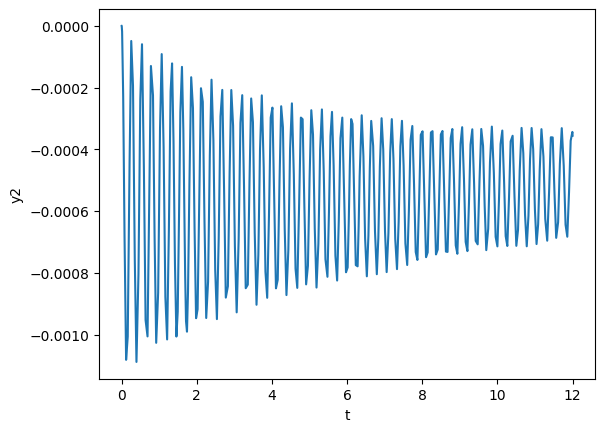

In [128]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

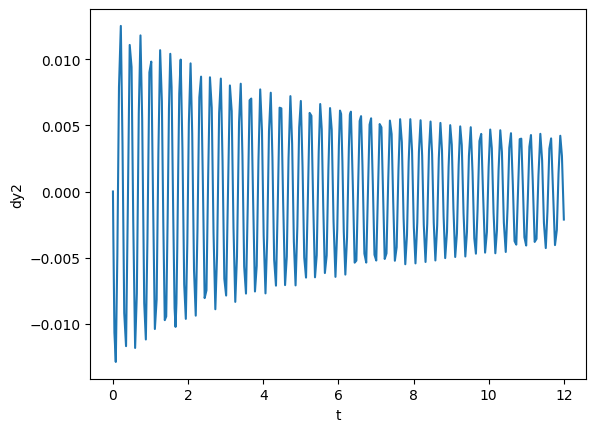

In [129]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

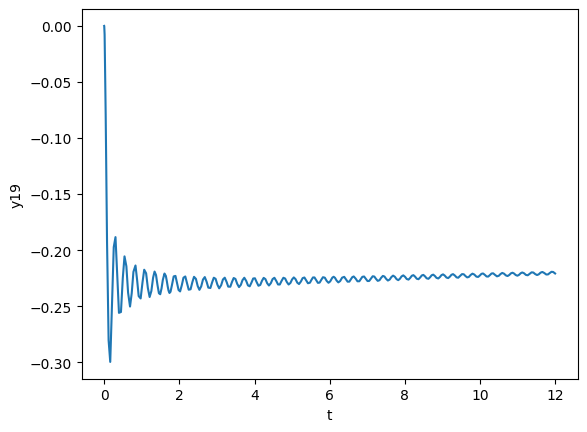

In [130]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

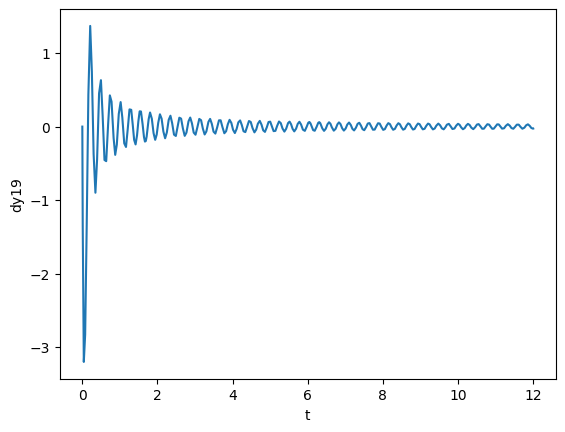

In [131]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

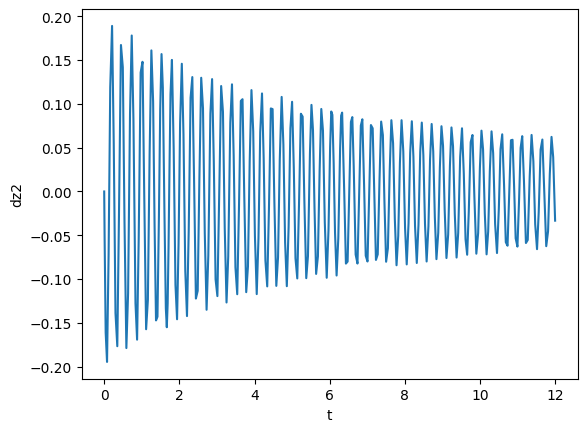

In [132]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

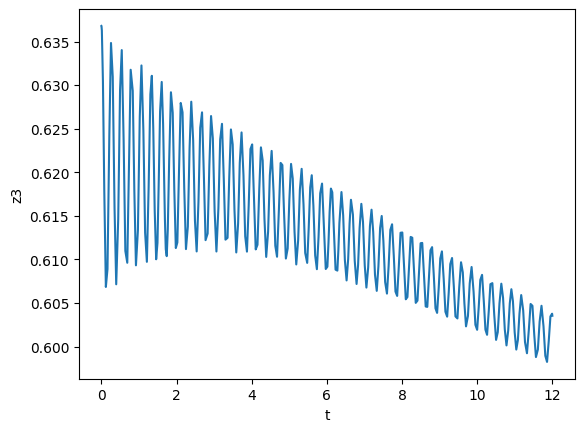

In [133]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

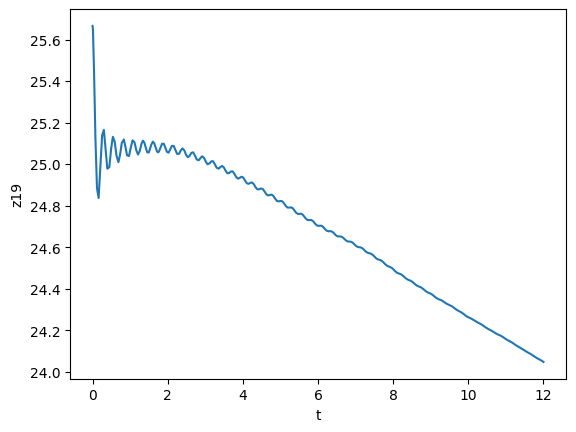

In [134]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

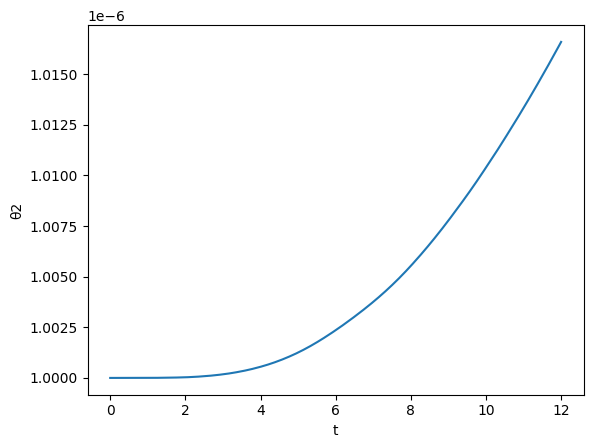

In [135]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

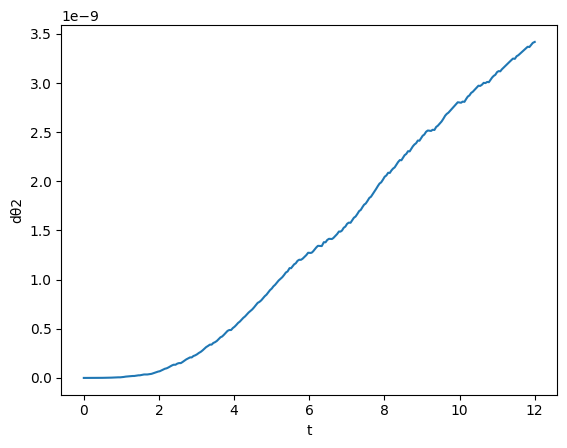

In [136]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

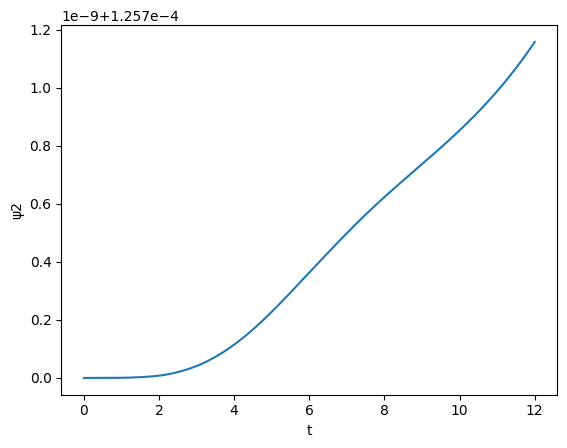

In [137]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

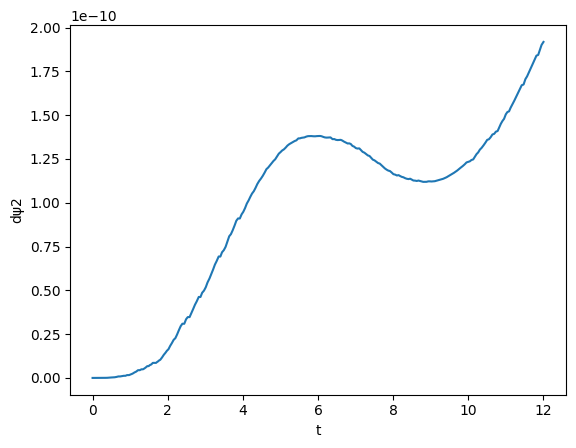

In [138]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

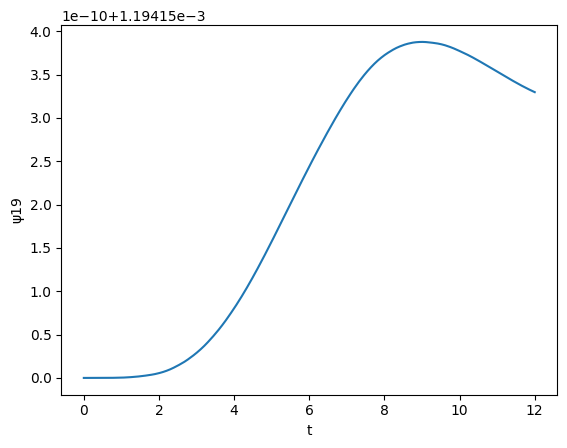

In [139]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [140]:
X010=us.T[:,0*N:1*N]

In [141]:
Y010=us.T[:,2*N:3*N]

In [142]:
Z010=us.T[:,4*N:5*N]

In [143]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()